In [1]:
!pip install ipython==8.12.0

In [2]:
import os, sys

USE_DRIVE = True
GH_REPO   = "https://github.com/47v0/cs4782-final-project.git"

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/gdrive")
    PROJECT_ROOT = "/content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project"
else:
    PROJECT_ROOT = "/content/cs4782-final-project"

if not os.path.exists(PROJECT_ROOT):
    !git clone {GH_REPO} "{PROJECT_ROOT}"
else:
    !cd "{PROJECT_ROOT}" && git fetch origin && git reset --hard origin/main && git clean -fd

CODE_DIR = f"{PROJECT_ROOT}/code"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# Unzip dataset (idempotent)
DATA_DIR = f"{PROJECT_ROOT}/data/all_six_datasets"
ZIP_PATH = f"{PROJECT_ROOT}/data/all_six_datasets.zip"
if not os.path.exists(DATA_DIR):
    !unzip -q "{ZIP_PATH}" -d "{PROJECT_ROOT}/data"

%load_ext autoreload
%autoreload 2

import torch
import pandas as pd
import matplotlib.pyplot as plt

print("PROJECT_ROOT:", PROJECT_ROOT)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/gdrive
Updating files: 100% (19/19), done.
HEAD is now at f0ec4cf Fix data path resolution; add OneCycleLR; track best_val_mae
PROJECT_ROOT: /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project
device: cuda


In [3]:
from train import paper_cfg, Trainer, build_dataloaders, build_model

cfg = paper_cfg()

# experiment
cfg["dataset"]  = "ETTh1"  # ETTh1 ETTh2 ETTm1 ETTm2 Weather Traffic Electricity ILI
cfg["seq_len"]  = 336      # look-back window  (PatchTST/42 uses L=336)
cfg["pred_len"] = 96       # forecast horizon  {96, 192, 336, 720}

# training
cfg["batch_size"] = 128
cfg["lr"]         = 1e-4
cfg["epochs"]     = 100
cfg["patience"]   = 10     # early-stopping on val MSE

# output paths — anchored to PROJECT_ROOT so they work from any cwd
cfg["checkpoint_dir"] = f"{PROJECT_ROOT}/results/checkpoints"
cfg["log_dir"]        = f"{PROJECT_ROOT}/results/logs"

print("Config:")
for k, v in cfg.items():
    print(f"  {k:22s} = {v}")

Config:
  dataset                = ETTh1
  data_root              = /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project/data/all_six_datasets
  seq_len                = 336
  pred_len               = 96
  patch_len              = 16
  stride                 = 8
  d_model                = 128
  n_heads                = 16
  n_layers               = 3
  d_ff                   = 256
  dropout                = 0.2
  batch_size             = 128
  lr                     = 0.0001
  pct_start              = 0.3
  epochs                 = 100
  patience               = 10
  device                 = cuda
  checkpoint_dir         = /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project/results/checkpoints
  log_dir                = /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project/results/logs
  num_workers            = 2
  seed                   = 2021


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(cfg)

x_batch, y_batch = next(iter(train_loader))
print(f"x shape: {tuple(x_batch.shape)}  ->  expected (batch, M, {cfg['seq_len']})")
print(f"y shape: {tuple(y_batch.shape)}  ->  expected (batch, M, {cfg['pred_len']})")


x shape: (128, 7, 336)  ->  expected (batch, M, 336)
y shape: (128, 7, 96)  ->  expected (batch, M, 96)


In [5]:
model = build_model(cfg)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

with torch.no_grad():
    dummy = torch.randn(4, x_batch.shape[1], cfg["seq_len"])
    out   = model(dummy.to(cfg["device"]))
    print(f"Output shape: {tuple(out.shape)}  ->  expected (4, {x_batch.shape[1]}, {cfg['pred_len']})")

Total params: 81,728
Output shape: (4, 7, 96)  ->  expected (4, 7, 96)


In [6]:
trainer = Trainer(cfg)
results = trainer.fit()

Training PatchTST | dataset=ETTh1 L=336 T=96 | device=cuda
  Model params: 81,728
------------------------------------------------------------
Epoch 001/100 | train MSE=0.7387 MAE=0.6205 | val   MSE=1.5972 MAE=0.9076 | 2.9s
  ===== New best val MSE=1.5972 MAE=0.9076 — checkpoint saved
Epoch 002/100 | train MSE=0.7076 MAE=0.6071 | val   MSE=1.5181 MAE=0.8833 | 2.3s
  ===== New best val MSE=1.5181 MAE=0.8833 — checkpoint saved
Epoch 003/100 | train MSE=0.6740 MAE=0.5923 | val   MSE=1.4327 MAE=0.8562 | 2.0s
  ===== New best val MSE=1.4327 MAE=0.8562 — checkpoint saved
Epoch 004/100 | train MSE=0.6387 MAE=0.5762 | val   MSE=1.3404 MAE=0.8257 | 2.0s
  ===== New best val MSE=1.3404 MAE=0.8257 — checkpoint saved
Epoch 005/100 | train MSE=0.5987 MAE=0.5574 | val   MSE=1.2459 MAE=0.7932 | 2.0s
  ===== New best val MSE=1.2459 MAE=0.7932 — checkpoint saved
Epoch 006/100 | train MSE=0.5606 MAE=0.5387 | val   MSE=1.1570 MAE=0.7609 | 2.0s
  ===== New best val MSE=1.1570 MAE=0.7609 — checkpoint saved

In [7]:
print("\n=== Results ===")
print(f"  Test MSE : {results['test_mse']:.4f}")
print(f"  Test MAE : {results['test_mae']:.4f}")
print(f"  Best epoch: {results['best_epoch']}")
print(f"  Paper target (ETTh1, T=96, L=336): MSE=0.375  MAE=0.399")

# 10% tolerance per the project plan
mse_in_band = 0.337 <= results["test_mse"] <= 0.413
mae_in_band = 0.359 <= results["test_mae"] <= 0.439
print(f"\n  MSE in 10% band [0.337, 0.413]: {'YES' if mse_in_band else 'NO'}")
print(f"  MAE in 10% band [0.359, 0.439]: {'YES' if mae_in_band else 'NO'}")



=== Results ===
  Test MSE : 0.3851
  Test MAE : 0.4024
  Best epoch: 39
  Paper target (ETTh1, T=96, L=336): MSE=0.375  MAE=0.399

  MSE in 10% band [0.337, 0.413]: YES
  MAE in 10% band [0.359, 0.439]: YES


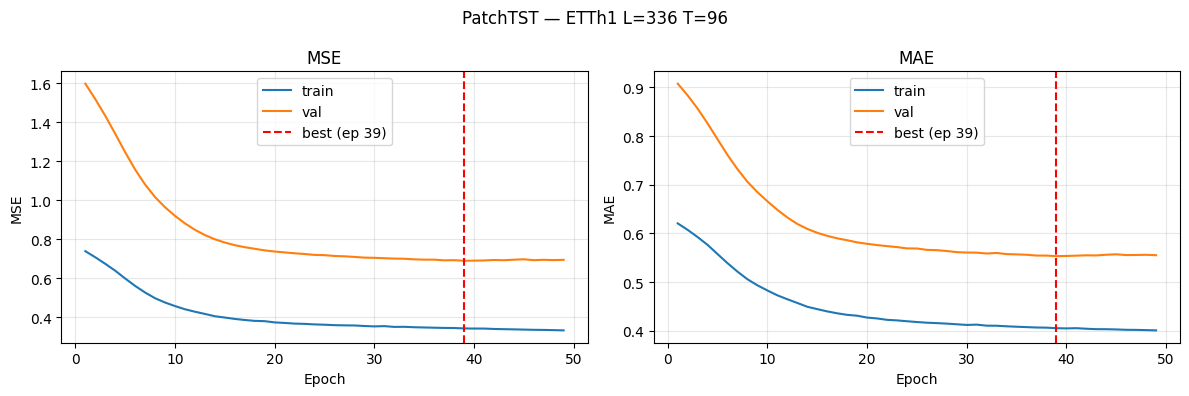

In [8]:
log_path = os.path.join(
    cfg["log_dir"],
    f"train_{cfg['dataset']}_L{cfg['seq_len']}_T{cfg['pred_len']}.csv"
)
df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["mse", "mae"]):
    ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
    ax.plot(df["epoch"], df[f"val_{metric}"],   label="val")
    ax.axvline(results["best_epoch"], color="red", ls="--",
               label=f"best (ep {results['best_epoch']})")
    ax.set_xlabel("Epoch"); ax.set_ylabel(metric.upper()); ax.set_title(metric.upper())
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f"PatchTST — {cfg['dataset']} L={cfg['seq_len']} T={cfg['pred_len']}")
plt.tight_layout(); plt.show()


In [9]:
# uncomment to run the full ETTh1 sweep (each takes ~10 min on T4)

# PAPER = {96: (0.375, 0.399), 192: (0.414, 0.421),
#          336: (0.431, 0.436), 720: (0.449, 0.466)}

# rows = []
# for T in [96, 192, 336, 720]:
#     print(f"\n{'='*50}\nT = {T}\n{'='*50}")
#     run_cfg = {**cfg, "pred_len": T}
#     res = Trainer(run_cfg).fit()
#     p_mse, p_mae = PAPER[T]
#     rows.append({"T": T,
#                  "Our MSE": round(res["test_mse"], 4), "Paper MSE": p_mse,
#                  "Our MAE": round(res["test_mae"], 4), "Paper MAE": p_mae})

# pd.DataFrame(rows).set_index("T")